In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
income = pd.read_csv("data/san_diego_income.csv")
zillow = pd.read_csv("data/zillow_home_values.csv")

In [3]:
income_clean = income.copy()

# Extract median household income row
median_row = income_clean[income_clean['Label (Grouping)'] == 'Median income (dollars)']

median_income = median_row["San Diego County, California!!Households!!Estimate"].values[0]

# remove commas
median_income = float(median_income.replace(",", ""))

print("Median Household Income:", median_income)

Median Household Income: 109132.0


In [4]:
sd_home = zillow[zillow["RegionName"] == "San Diego County"]

In [5]:
sd_home

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,StateCodeFIPS,MunicipalCodeFIPS,2000-01-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31
4,2841,4,San Diego County,county,CA,CA,"San Diego-Chula Vista-Carlsbad, CA",6,73,210703.817869,...,919396.983969,914664.101695,909523.90246,905227.788816,901869.469439,900047.881347,900016.924724,900997.603262,903114.130925,904312.219896


In [6]:
price_data = sd_home.drop(columns=[
    "RegionID","SizeRank","RegionName","RegionType",
    "StateName","State","Metro","StateCodeFIPS","MunicipalCodeFIPS"
])

price_series = price_data.melt(var_name="date", value_name="home_value")

price_series["date"] = pd.to_datetime(price_series["date"])
price_series = price_series.sort_values("date")

In [7]:
price_series["year"] = price_series["date"].dt.year

yearly_prices = price_series.groupby("year")["home_value"].mean().reset_index()

In [8]:
yearly_prices["median_income"] = median_income

In [9]:
yearly_prices["price_income_ratio"] = yearly_prices["home_value"] / yearly_prices["median_income"]

In [10]:
yearly_prices["monthly_payment"] = yearly_prices["home_value"] * 0.005

In [11]:
yearly_prices["housing_burden"] = yearly_prices["monthly_payment"] / (yearly_prices["median_income"]/12)

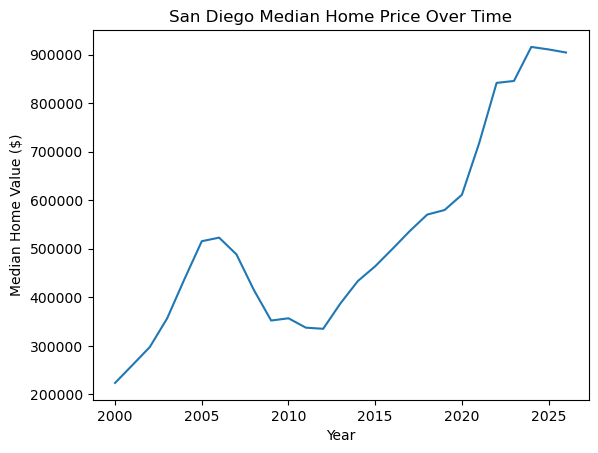

In [12]:
plt.figure()
plt.plot(yearly_prices["year"], yearly_prices["home_value"])

plt.title("San Diego Median Home Price Over Time")
plt.xlabel("Year")
plt.ylabel("Median Home Value ($)")
plt.show()

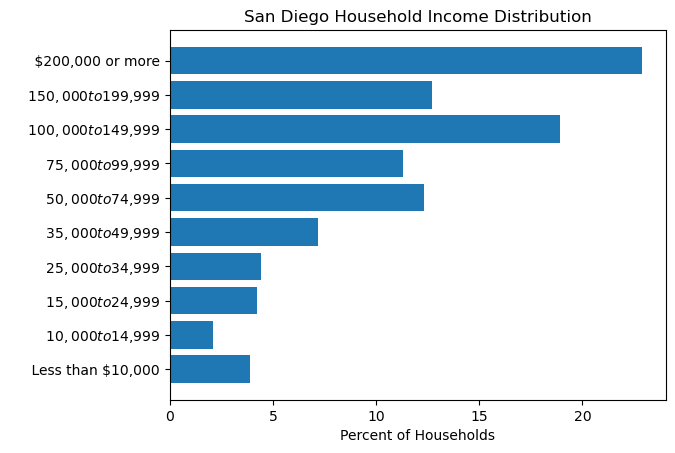

In [13]:
income_brackets = income.iloc[1:11]

labels = income_brackets["Label (Grouping)"]
values = income_brackets["San Diego County, California!!Households!!Estimate"].str.replace("%","").astype(float)

plt.figure()
plt.barh(labels, values)

plt.title("San Diego Household Income Distribution")
plt.xlabel("Percent of Households")
plt.show()